# Ablation — does fruit-bat repertoire differ by behavioural context?

**Question.** Assom's pipeline clusters all segments globally with HDBSCAN and
finds 7 syllable types. Does this global repertoire *describe each context
adequately*, or does it hide context-specific types that would emerge from
per-context clustering?

**Why this matters.** If global HDBSCAN under-segments conflict contexts
(Fighting, Mating Protest) while over-segmenting simple ones (Isolation),
then an *adaptive* tokeniser — which can split / merge clusters conditionally
— should be able to recover those hidden types. That is the motivation for
the thesis's adaptive-vocabulary approach.

**Why this is only an ablation, not a replacement.** Per-context HDBSCAN
breaks cross-context comparability (cluster IDs live in different spaces),
so it cannot be used for HP1 / HP2 / HP3 directly — those tests require a
shared vocabulary. We also use severely imbalanced data (Isolation = 1948
sequences vs Kissing = 88), which makes per-context HDBSCAN parameters
non-comparable unless we use fixed `min_cluster_size`.

**Design.** Four runs on the *same* segments and the *same* UMAP embedding:

| Run | What | Question it answers |
|---|---|---|
| A | Global HDBSCAN labels projected per context | How is the shared repertoire USED per context? |
| B | Per-context HDBSCAN on the global UMAP with **fixed** `mcs=20` | Does each context internally cluster into more types than global gives? |
| C | Per-context UMAP + HDBSCAN (fully recomputed) | Is the *geometry* of per-context repertoire even similar to global? |
| D | Distance to nearest global centroid | Are there segments that don't fit any global cluster? |

Outputs: tables, heatmaps, honest verdict.


In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import umap, hdbscan

from sklearn.metrics import (
    silhouette_score, adjusted_rand_score, normalized_mutual_info_score,
)
from scipy.spatial.distance import cdist
from scipy.stats import entropy

CHECKPOINT_DIR = Path('/Volumes/T7/cache/assom_paper_repro')
state = joblib.load(CHECKPOINT_DIR / 'ablation_state.joblib')

seg_df         = state['seg_df']
tf_specs       = state['tf_specs']           # (N, 6, 32)
embedding      = state['embedding']          # (N, 2)
hdbscan_labels = state['hdbscan_labels']     # (N,)
hdb_nca_labels = state['hdb_nca_labels']     # (N,)
CONTEXT_DICT   = state['CONTEXT_DICT']
UMAP_CFG = dict(
    n_neighbors=state['UMAP_N_NEIGHBORS'],
    min_dist=state['UMAP_MIN_DIST'],
    metric=state['UMAP_METRIC'],
    random_state=state['UMAP_SEED'],
)
HDB_CFG = dict(
    min_samples=state['HDBSCAN_MIN_SAMPLES'],
    cluster_selection_epsilon=state['HDBSCAN_EPSILON'],
    cluster_selection_method=state['HDBSCAN_METHOD'],
)

print(f'Segments: {len(seg_df)}')
print(f'Global HDBSCAN clusters: {len(set(hdbscan_labels)) - (1 if -1 in hdbscan_labels else 0)}')
print(f'After NCA: {len(set(hdb_nca_labels))}')
print(f'Contexts: {seg_df["context_name"].value_counts().to_dict()}')


Segments: 53455
Global HDBSCAN clusters: 6
After NCA: 6
Contexts: {'Mating protest': 16978, 'Isolation': 12384, 'Fighting': 6130, 'Feeding': 5653, 'Biting': 4096, 'Threat-like': 3575, 'Separation': 3298, 'Grooming': 845, 'Kissing': 483, 'Landing': 13}


## Run A — global repertoire usage per context

For each context, show which global clusters are used and with what frequency.
This is essentially HP2 reframed as a diagnostic.


In [2]:
seg_df['syllable_id'] = hdb_nca_labels   # use NCA-reassigned labels
contexts_present = sorted(seg_df['context_name'].unique())

global_ids = sorted(set(hdb_nca_labels))
freq_matrix = pd.DataFrame(0.0, index=contexts_present, columns=global_ids)
count_matrix = pd.DataFrame(0, index=contexts_present, columns=global_ids)

for ctx in contexts_present:
    sub = seg_df[seg_df['context_name'] == ctx]
    counts = sub['syllable_id'].value_counts()
    total = counts.sum()
    for gid in global_ids:
        count_matrix.loc[ctx, gid] = int(counts.get(gid, 0))
        freq_matrix.loc[ctx, gid] = float(counts.get(gid, 0) / total) if total else 0

print('Global cluster usage per context (count):')
print(count_matrix)
print('\nGlobal cluster usage per context (fraction):')
print(freq_matrix.round(3))

# Entropy of cluster usage per context — measures how spread out the repertoire is
entropies = {}
for ctx in contexts_present:
    p = freq_matrix.loc[ctx].values
    p = p[p > 0]
    entropies[ctx] = float(entropy(p, base=2))

print('\nRepertoire entropy per context (bits):')
for ctx, e in sorted(entropies.items(), key=lambda x: -x[1]):
    n_active = int((freq_matrix.loc[ctx] > 0.01).sum())
    print(f'  {ctx:16s} H={e:.2f}  active_clusters={n_active}/{len(global_ids)}  N={count_matrix.loc[ctx].sum()}')


Global cluster usage per context (count):
                   0     1      2     3     4     5
Biting          1119   250     74    14   183  2456
Feeding         1408   589    140    94   570  2852
Fighting        1694  1272    201    26   407  2530
Grooming         199    39      7     3    32   565
Isolation        379   147  10626    18    71  1143
Kissing          113    16      2     3    24   325
Landing            3     0      0     0     0    10
Mating protest  3123  2938    251    88  1721  8857
Separation       132   214    184  1753    36   979
Threat-like     1004   948     63    33   361  1166

Global cluster usage per context (fraction):
                    0      1      2      3      4      5
Biting          0.273  0.061  0.018  0.003  0.045  0.600
Feeding         0.249  0.104  0.025  0.017  0.101  0.505
Fighting        0.276  0.208  0.033  0.004  0.066  0.413
Grooming        0.236  0.046  0.008  0.004  0.038  0.669
Isolation       0.031  0.012  0.858  0.001  0.006  0.09

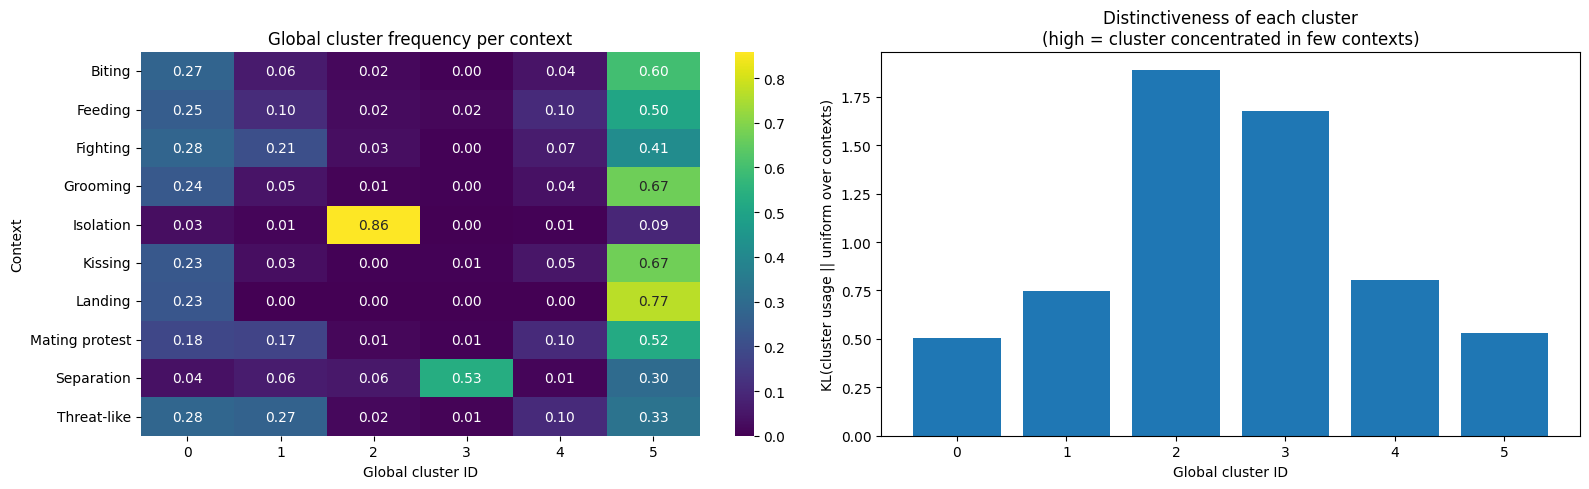


--- Cluster ownership ---
  Cluster 0: top context = Mating protest (34.0% of its usage)  KL=0.50
  Cluster 1: top context = Mating protest (45.8% of its usage)  KL=0.75
  Cluster 2: top context = Isolation (92.0% of its usage)  KL=1.89
  Cluster 3: top context = Separation (86.3% of its usage)  KL=1.68
  Cluster 4: top context = Mating protest (50.5% of its usage)  KL=0.80
  Cluster 5: top context = Mating protest (42.4% of its usage)  KL=0.53


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(freq_matrix, annot=True, fmt='.2f', cmap='viridis', ax=axes[0])
axes[0].set_title('Global cluster frequency per context')
axes[0].set_xlabel('Global cluster ID')
axes[0].set_ylabel('Context')

# Distinctiveness: which clusters are characteristic of which context?
# Compute KL divergence of context distribution from uniform
from scipy.stats import entropy as kl_entropy
uniform = np.ones(len(contexts_present)) / len(contexts_present)
distinctiveness = {}
for gid in global_ids:
    col = count_matrix[gid].values.astype(float)
    col = col / col.sum() if col.sum() else uniform
    distinctiveness[gid] = float(kl_entropy(col, uniform))

ax = axes[1]
ax.bar(list(distinctiveness.keys()), list(distinctiveness.values()))
ax.set_xlabel('Global cluster ID')
ax.set_ylabel('KL(cluster usage || uniform over contexts)')
ax.set_title('Distinctiveness of each cluster\n(high = cluster concentrated in few contexts)')
plt.tight_layout(); plt.show()

# Which cluster is "owned" by which context?
print('\n--- Cluster ownership ---')
for gid in global_ids:
    col = count_matrix[gid].values.astype(float)
    if col.sum() == 0:
        continue
    probs = col / col.sum()
    top_ctx = contexts_present[np.argmax(probs)]
    print(f'  Cluster {gid}: top context = {top_ctx} ({probs.max()*100:.1f}% of its usage)  KL={distinctiveness[gid]:.2f}')


## Run B — per-context HDBSCAN on the **global** UMAP embedding

Fixed `min_cluster_size = 20` across contexts (paper-style fractional would
ruin comparability because Kissing has 88 segments, Isolation 1948).

The point: within the acoustic manifold that global HDBSCAN saw, are there
finer-grained types per context?


In [4]:
MCS_PER_CTX = 20   # fixed across contexts for comparability

per_ctx_B = {}
for ctx in contexts_present:
    mask = (seg_df['context_name'] == ctx).values
    emb_ctx = embedding[mask]
    n = len(emb_ctx)
    if n < MCS_PER_CTX * 2:
        per_ctx_B[ctx] = dict(n=n, n_clusters=0, noise_frac=1.0, silhouette=np.nan)
        continue
    clust = hdbscan.HDBSCAN(min_cluster_size=MCS_PER_CTX, **HDB_CFG).fit(emb_ctx)
    labs = clust.labels_
    n_cl = len(set(labs)) - (1 if -1 in labs else 0)
    nf = float((labs == -1).mean())
    sil = float(silhouette_score(emb_ctx[labs >= 0], labs[labs >= 0])) if n_cl >= 2 and (labs >= 0).sum() > n_cl else np.nan
    per_ctx_B[ctx] = dict(n=n, n_clusters=n_cl, noise_frac=nf, silhouette=sil, labels=labs, mask=mask)

print(f'Per-context HDBSCAN (global UMAP, min_cluster_size={MCS_PER_CTX}):')
print(f'  {"Context":16s}  {"N":>5s}  {"n_cl":>5s}  {"noise%":>7s}  {"silh":>6s}')
for ctx, d in sorted(per_ctx_B.items(), key=lambda x: -x[1]['n']):
    sil_str = f'{d["silhouette"]:.3f}' if not np.isnan(d['silhouette']) else '  nan'
    print(f'  {ctx:16s}  {d["n"]:5d}  {d["n_clusters"]:5d}  {d["noise_frac"]*100:6.1f}%  {sil_str}')

total_per_ctx = sum(d['n_clusters'] for d in per_ctx_B.values())
global_n = len(set(hdb_nca_labels))
print(f'\nSum of per-context clusters: {total_per_ctx}')
print(f'Global clusters (after NCA): {global_n}')
print(f'Ratio: {total_per_ctx/global_n:.1f}× more types emerge when clustering per-context')


Per-context HDBSCAN (global UMAP, min_cluster_size=20):
  Context               N   n_cl   noise%    silh
  Mating protest    16978     71    75.9%  0.456
  Isolation         12384     27    50.4%  -0.120
  Fighting           6130     27    71.1%  0.570
  Feeding            5653     29    73.1%  0.574
  Biting             4096     17    81.2%  0.700
  Threat-like        3575     21    60.4%  0.542
  Separation         3298     12    55.5%  0.509
  Grooming            845      3     0.0%  0.863
  Kissing             483      2     0.0%  0.851
  Landing              13      0   100.0%    nan

Sum of per-context clusters: 209
Global clusters (after NCA): 6
Ratio: 34.8× more types emerge when clustering per-context


## Run C — per-context **UMAP + HDBSCAN** (fully recomputed)

Most extreme per-context run: both dimensionality reduction and clustering
are redone from scratch on each context's mel features. Answers: is the
per-context *geometry* itself different, or just the density structure?

Heavy step — limit to contexts with ≥ 200 segments to keep UMAP stable.


In [5]:
MCS_PER_CTX_C = 20
per_ctx_C = {}

for ctx in contexts_present:
    mask = (seg_df['context_name'] == ctx).values
    X_ctx = tf_specs[mask].reshape(mask.sum(), -1)   # (N_ctx, 192)
    n = X_ctx.shape[0]
    if n < 200:
        per_ctx_C[ctx] = dict(n=n, skipped=True)
        continue
    reducer = umap.UMAP(n_components=2, **UMAP_CFG, n_jobs=-1)
    emb_ctx = reducer.fit_transform(X_ctx)
    clust = hdbscan.HDBSCAN(min_cluster_size=MCS_PER_CTX_C, **HDB_CFG).fit(emb_ctx)
    labs = clust.labels_
    n_cl = len(set(labs)) - (1 if -1 in labs else 0)
    nf = float((labs == -1).mean())
    sil = float(silhouette_score(emb_ctx[labs >= 0], labs[labs >= 0])) if n_cl >= 2 and (labs >= 0).sum() > n_cl else np.nan
    per_ctx_C[ctx] = dict(n=n, n_clusters=n_cl, noise_frac=nf, silhouette=sil,
                          embedding=emb_ctx, labels=labs, mask=mask)

print('\nPer-context FULL UMAP+HDBSCAN (≥200 seg):')
print(f'  {"Context":16s}  {"N":>5s}  {"n_cl":>5s}  {"noise%":>7s}  {"silh":>6s}')
for ctx, d in sorted(per_ctx_C.items(), key=lambda x: -x[1].get('n', 0)):
    if d.get('skipped'):
        print(f'  {ctx:16s}  {d["n"]:5d}   —      —       skipped (<200 seg)')
        continue
    sil_str = f'{d["silhouette"]:.3f}' if not np.isnan(d['silhouette']) else '  nan'
    print(f'  {ctx:16s}  {d["n"]:5d}  {d["n_clusters"]:5d}  {d["noise_frac"]*100:6.1f}%  {sil_str}')



Per-context FULL UMAP+HDBSCAN (≥200 seg):
  Context               N   n_cl   noise%    silh
  Mating protest    16978     88    72.8%  0.502
  Isolation         12384     63    71.9%  0.587
  Fighting           6130     30    66.0%  0.543
  Feeding            5653     35    71.1%  0.555
  Biting             4096     23    71.7%  0.547
  Threat-like        3575     25    64.0%  0.586
  Separation         3298     22    68.8%  0.676
  Grooming            845      5    55.5%  0.783
  Kissing             483      3    53.4%  0.845
  Landing              13   —      —       skipped (<200 seg)


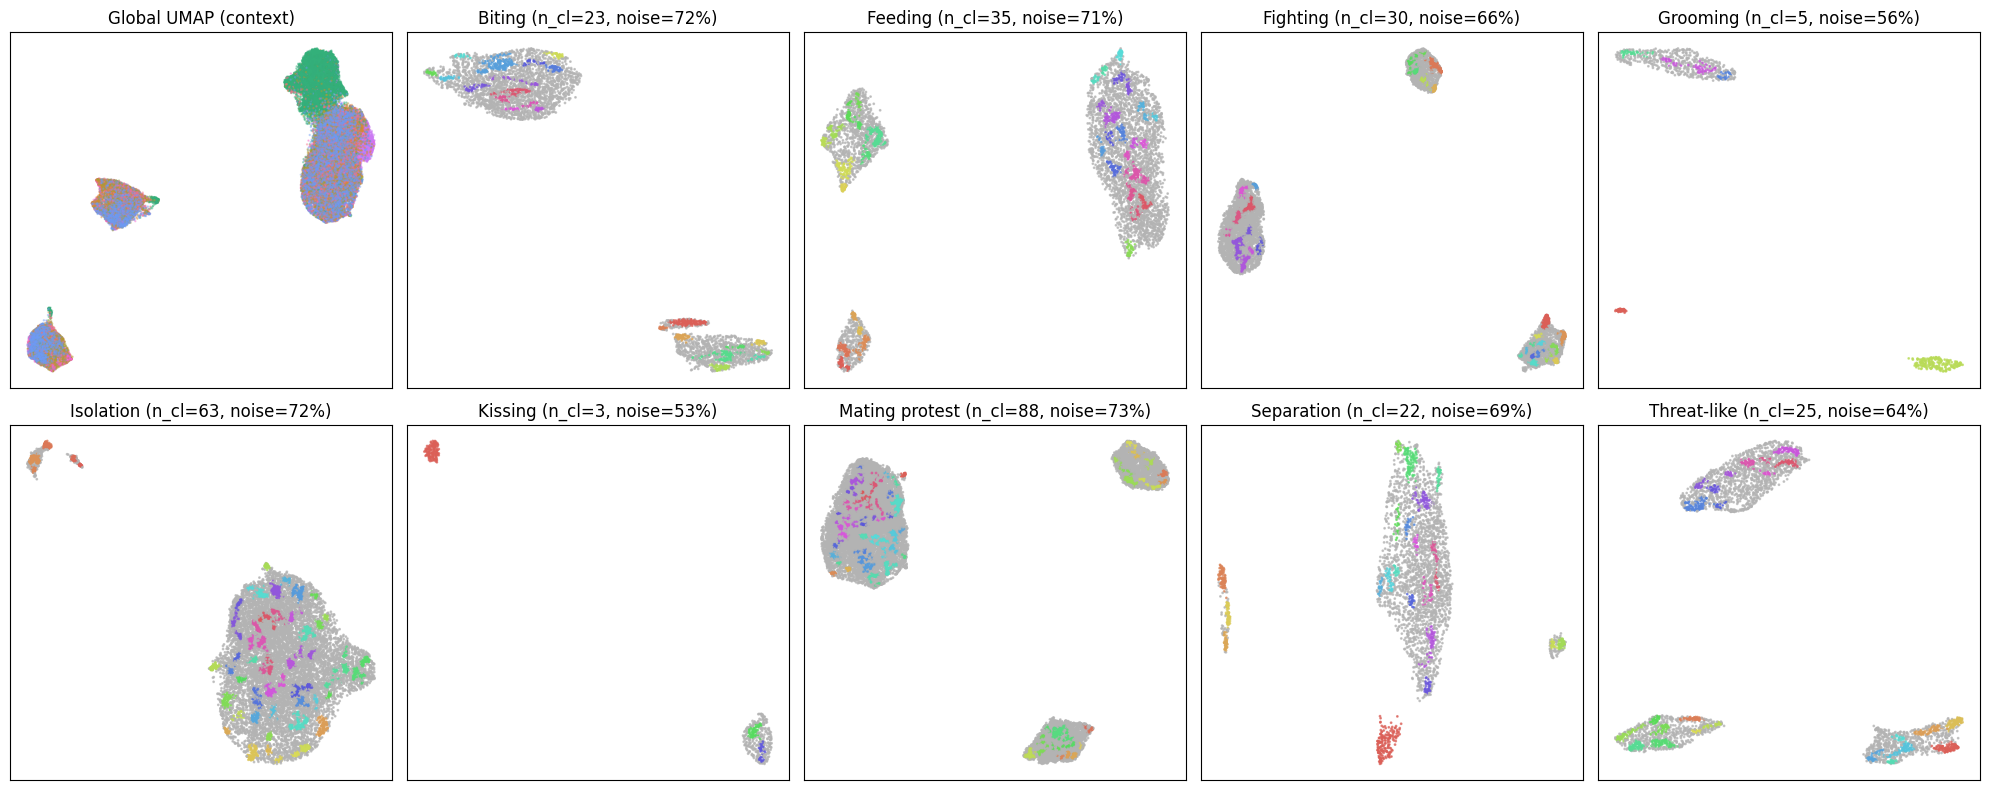

In [6]:
# Visualise: how does per-context UMAP look vs global UMAP coloured by context?
contexts_with_C = [c for c, d in per_ctx_C.items() if not d.get('skipped')]
n_panels = len(contexts_with_C) + 1

fig, axes = plt.subplots(2, (n_panels + 1) // 2, figsize=(4 * ((n_panels + 1) // 2), 8))
axes = axes.flatten()

pal_ctx = sns.color_palette('husl', len(contexts_present))
cmap_ctx = dict(zip(contexts_present, pal_ctx))

# panel 0: global UMAP coloured by context
axes[0].scatter(embedding[:, 0], embedding[:, 1],
                c=[cmap_ctx[c] for c in seg_df['context_name']],
                s=0.5, alpha=0.4)
axes[0].set_title('Global UMAP (context)')

for i, ctx in enumerate(contexts_with_C, start=1):
    d = per_ctx_C[ctx]
    emb_ctx = d['embedding']; labs = d['labels']
    n_cl = d['n_clusters']
    palette = sns.color_palette('hls', max(n_cl, 1))
    colors = [(.7,.7,.7) if l == -1 else palette[l] for l in labs]
    axes[i].scatter(emb_ctx[:, 0], emb_ctx[:, 1], c=colors, s=1.0, alpha=0.7)
    axes[i].set_title(f'{ctx} (n_cl={n_cl}, noise={d["noise_frac"]*100:.0f}%)')

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for i in range(n_panels, len(axes)):
    axes[i].axis('off')
plt.tight_layout(); plt.show()


## Run D — distance to nearest global centroid

Are there segments that are *far* from every global cluster centroid? If yes,
they hint at context-specific types the global repertoire missed.

We compute per-segment distance to nearest global centroid (in UMAP space),
then histogram per context.


Global 95th-percentile distance: 2.881

Fraction of segments further than 95th-pct from any centroid (per context):
  Landing            15.4%  (N=13)
  Grooming            8.6%  (N=845)
  Biting              7.2%  (N=4096)
  Isolation           7.1%  (N=12384)
  Fighting            5.1%  (N=6130)
  Kissing             4.3%  (N=483)
  Feeding             4.2%  (N=5653)
  Mating protest      3.8%  (N=16978)
  Threat-like         3.3%  (N=3575)
  Separation          3.0%  (N=3298)


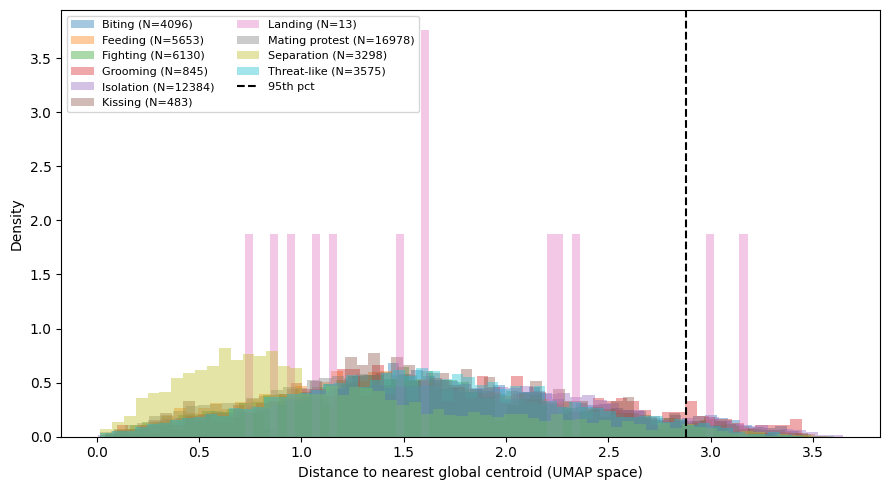

In [7]:
# Compute global cluster centroids in UMAP space
centroids = {}
for gid in sorted(set(hdb_nca_labels)):
    centroids[gid] = embedding[hdb_nca_labels == gid].mean(axis=0)
C = np.stack([centroids[g] for g in sorted(centroids)])

dists = cdist(embedding, C, metric='euclidean')
min_dist = dists.min(axis=1)
nearest  = dists.argmin(axis=1)
seg_df['min_dist_to_centroid'] = min_dist

# Per context: fraction of segments with distance > 95% global quantile
threshold = np.quantile(min_dist, 0.95)
print(f'Global 95th-percentile distance: {threshold:.3f}')
outlier_fractions = {}
for ctx in contexts_present:
    sub = seg_df[seg_df['context_name'] == ctx]
    frac = float((sub['min_dist_to_centroid'] > threshold).mean())
    outlier_fractions[ctx] = frac

print('\nFraction of segments further than 95th-pct from any centroid (per context):')
for ctx, f in sorted(outlier_fractions.items(), key=lambda x: -x[1]):
    N = (seg_df['context_name'] == ctx).sum()
    print(f'  {ctx:16s}  {f*100:5.1f}%  (N={N})')

fig, ax = plt.subplots(figsize=(9, 5))
for ctx in contexts_present:
    sub = seg_df[seg_df['context_name'] == ctx]['min_dist_to_centroid']
    ax.hist(sub, bins=60, alpha=0.4, label=f'{ctx} (N={len(sub)})', density=True)
ax.axvline(threshold, color='k', linestyle='--', label='95th pct')
ax.set_xlabel('Distance to nearest global centroid (UMAP space)')
ax.set_ylabel('Density')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


## Summary table — all three runs side by side


In [8]:
rows = []
for ctx in contexts_present:
    n = int((seg_df['context_name'] == ctx).sum())
    n_active_global = int((freq_matrix.loc[ctx] > 0.01).sum())
    H = entropies[ctx]
    n_B = per_ctx_B[ctx]['n_clusters']
    sil_B = per_ctx_B[ctx]['silhouette']
    C_d = per_ctx_C.get(ctx, {'skipped': True})
    n_C = C_d.get('n_clusters', np.nan)
    sil_C = C_d.get('silhouette', np.nan)
    out_frac = outlier_fractions[ctx]
    rows.append({
        'context': ctx,
        'N': n,
        'global_H': round(H, 2),
        'active_global': n_active_global,
        'per_ctx_B (global UMAP)': n_B,
        'silh_B': round(sil_B, 3) if not np.isnan(sil_B) else np.nan,
        'per_ctx_C (own UMAP)': n_C,
        'silh_C': round(sil_C, 3) if not np.isnan(sil_C) else np.nan,
        'outlier_pct': round(out_frac * 100, 1),
    })

summary = pd.DataFrame(rows).sort_values('N', ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))


       context     N  global_H  active_global  per_ctx_B (global UMAP)  silh_B  per_ctx_C (own UMAP)  silh_C  outlier_pct
Mating protest 16978      1.84              5                       71   0.456                  88.0   0.502          3.8
     Isolation 12384      0.79              4                       27  -0.120                  63.0   0.587          7.1
      Fighting  6130      1.97              5                       27   0.570                  30.0   0.543          5.1
       Feeding  5653      1.90              6                       29   0.574                  35.0   0.555          4.2
        Biting  4096      1.53              5                       17   0.700                  23.0   0.547          7.2
   Threat-like  3575      2.05              5                       21   0.542                  25.0   0.586          3.3
    Separation  3298      1.75              6                       12   0.509                  22.0   0.676          3.0
      Grooming   845    

## Verdict

Read this table with the following in mind:

1. **`active_global` vs `per_ctx_B`.** If `per_ctx_B > active_global` by a lot,
   the context has fine-grained structure that global HDBSCAN merged. The
   global repertoire under-represents this context.

2. **`silh_B` and `silh_C`.** Low silhouette in per-context runs means the
   context doesn't have well-separated internal structure — the "extra"
   clusters are probably noise, not real sub-types. High silhouette means
   real structure is hidden.

3. **`outlier_pct`.** High per-context outlier percentage = many segments in
   that context are far from every global centroid. This is the clearest
   signal that a context-specific type exists.

4. **Do NOT use per-context labels for HP1 / HP2.** They are NOT comparable
   across contexts. This is a diagnostic only.

5. **Imbalance warning.** Contexts with N < ~200 (e.g. Kissing, Separation)
   produce unreliable per-context clustering regardless of method. Treat
   their per-context numbers as noise.

### How this motivates adaptive tokenisation

If Fighting / Mating Protest show `per_ctx_B > active_global` with decent
silhouette AND high `outlier_pct`, that is direct evidence that:

- Global HDBSCAN leaves context-specific acoustic types on the table
- An adaptive tokeniser with split operations could recover them
- Doing so should improve HP1 (more discriminative features per sequence)
  and enrich MR / network analyses

Conversely, if the table shows `per_ctx_B ≈ active_global` uniformly with
flat silhouette, the global repertoire is already doing its job — and
adaptive splitting risks over-fitting.

**Bottom line for the thesis:** this ablation is the empirical case for
*why* the adaptive tokeniser should include split-by-context-residual logic
(or NOT, depending on what the table says). Run it, read the table, report
it honestly.
